# Customer Churn Prediction

In [ ]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report


In [1]:
df= pd.read_csv("/home/sanjay/Internship/datasets/Churn_Modelling.csv")
df.head()

NameError: name 'pd' is not defined

# Feature Engineering & Data Preprocessing

In [ ]:
df.shape

(10000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [ ]:
df.drop(columns={'RowNumber','CustomerId','Surname'},inplace=True)

In [ ]:
df.head(2)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0


# Expolatry Data Analysis

/tmp/ipykernel_203910/319029013.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df,palette=['green','red'])


Text(0.5, 1.0, 'Customer Churn Count')

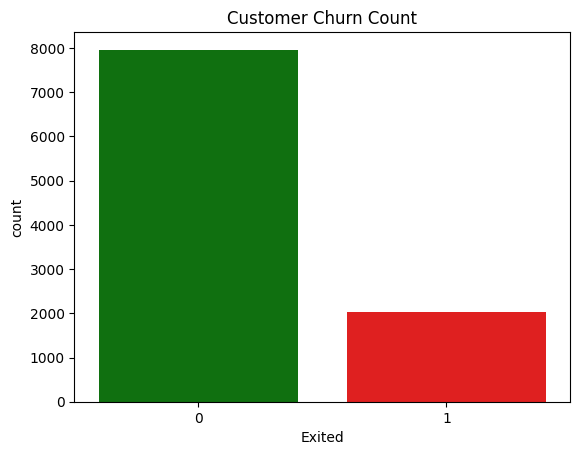

In [ ]:
sns.countplot(x='Exited', data=df,palette=['green','red'])
plt.title('Customer Churn Count') 


From above Graph we can see around 8k customer are not leaving and 2k customer are leaving so bank should focous on those 2k customer`s feedback why they are leaving and focuos on there requieriments.

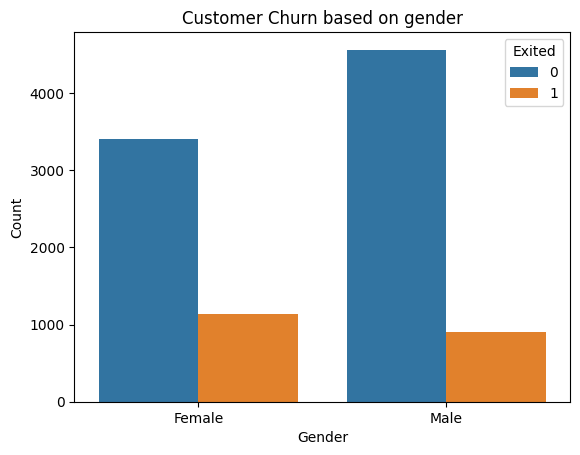

In [ ]:
GE=sns.countplot(x='Gender',hue='Exited',data=df)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Customer Churn based on gender")
plt.show()

**Customer Churn based on Gender**

* The bar chart shows the relationship between Gender and Customer Churn.

* The majority of both Male and Female customers did not exit (Exited = 0).

* However, a slightly higher number of females have churned (Exited = 1) compared to males.

* This suggests that female customers are more likely to leave the service than male customers.

The company may need to analyze why female customers are less retained — possibly due to differences in satisfaction, offers, or service experience.

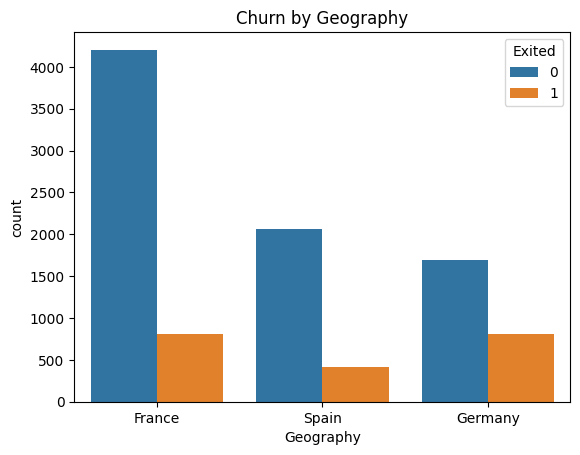

In [ ]:
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title('Churn by Geography')
plt.show()


**From the above chart, we can observe that:**

* France has the highest number of customers overall, but a relatively lower churn ratio compared to its total customers.

* Germany shows a higher churn proportion, indicating that a larger percentage of German customers are leaving the bank.

* Spain has the lowest customer count and churn rate among the three.

**Insight:**
* The German market seems more unstable, with customers more likely to churn. The bank should focus on understanding the causes — possibly customer dissatisfaction, service issues, or better offers from competitors — and implement targeted retention strategies there.

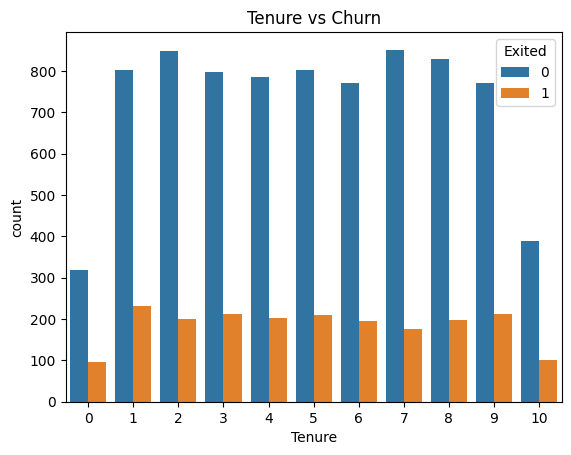

In [ ]:
sns.countplot(x='Tenure', hue='Exited', data=df)
plt.title('Tenure vs Churn')
plt.show()



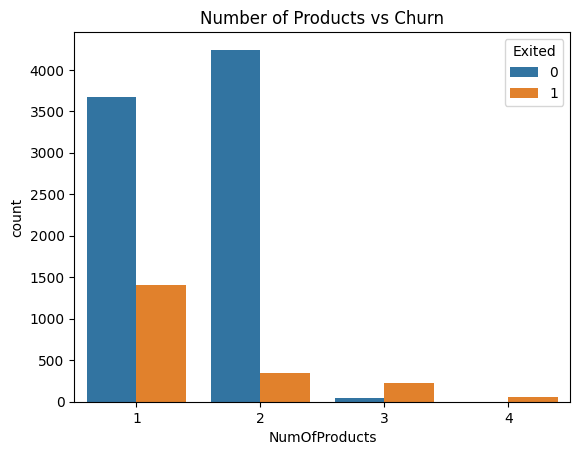

In [ ]:
sns.countplot(x='NumOfProducts', hue='Exited', data=df)
plt.title('Number of Products vs Churn')
plt.show()


<Axes: xlabel='Exited', ylabel='Age'>

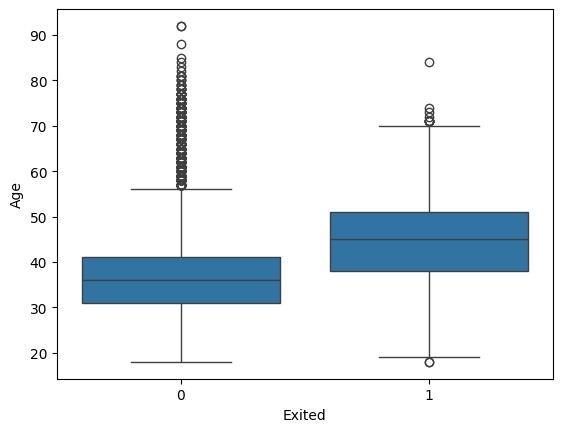

In [ ]:
# boxplot between Age and Exited
sns.boxplot(x='Exited',y='Age',data=df)

From above boxplot we can see most of the customers who are leaving are between 38 and 50 years old:

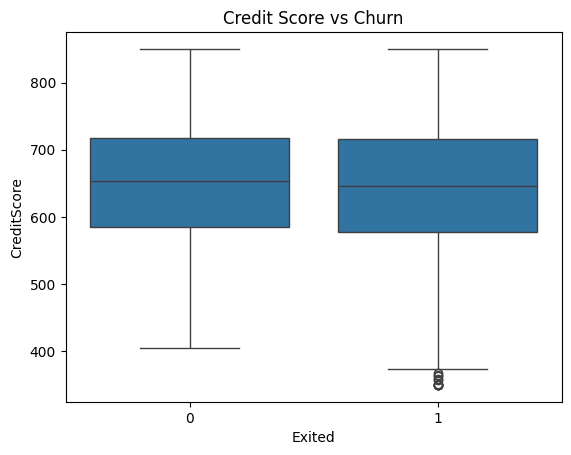

In [ ]:

# boxplot between Credit Score vs Churn
sns.boxplot(x='Exited', y='CreditScore', data=df)
plt.title('Credit Score vs Churn')
plt.show()


From above boxplot we can see customer who exit or customer who stay both have same credit score .So it means credit score did not affect customer churn

In [ ]:
# use for loop for replace Famale with 0 & Male with 1
for col in df.columns:
    df['Gender'].replace("Female",'0',inplace=True)
    df['Gender'].replace('Male',1,inplace=True)

/tmp/ipykernel_203910/996438699.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].replace("Female",'0',inplace=True)
/tmp/ipykernel_203910/996438699.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [ ]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [ ]:
df = pd.get_dummies(df, columns=['Geography'], drop_first=True,dtype=int)

In [ ]:
x = df.drop('Exited', axis=1)
y = df['Exited']
x


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,1
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,0
9997,709,0,36,7,0.00,1,0,1,42085.58,0,0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,0


In [ ]:
 
sc = StandardScaler()
X_scaled = sc.fit_transform(x)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



In [ ]:

model = Sequential([
    Dense(16, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.3),
    Dense(8, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/home/sanjay/Internship/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-21 10:23:51.805032: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7489 - loss: 0.5597 - val_accuracy: 0.7987 - val_loss: 0.4768
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7897 - loss: 0.4953 - val_accuracy: 0.7987 - val_loss: 0.4463
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7909 - loss: 0.4788 - val_accuracy: 0.7987 - val_loss: 0.4329
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7939 - loss: 0.4672 - val_accuracy: 0.7994 - val_loss: 0.4253
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7955 - loss: 0.4584 - val_accuracy: 0.8050 - val_loss: 0.4200
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7987 - loss: 0.4535 - val_accuracy: 0.8150 - val_loss: 0.4151
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8100 - loss: 0.4480 - val_accuracy: 0.8150 - val_loss: 0.4097
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8112 - loss: 0.4386 - va

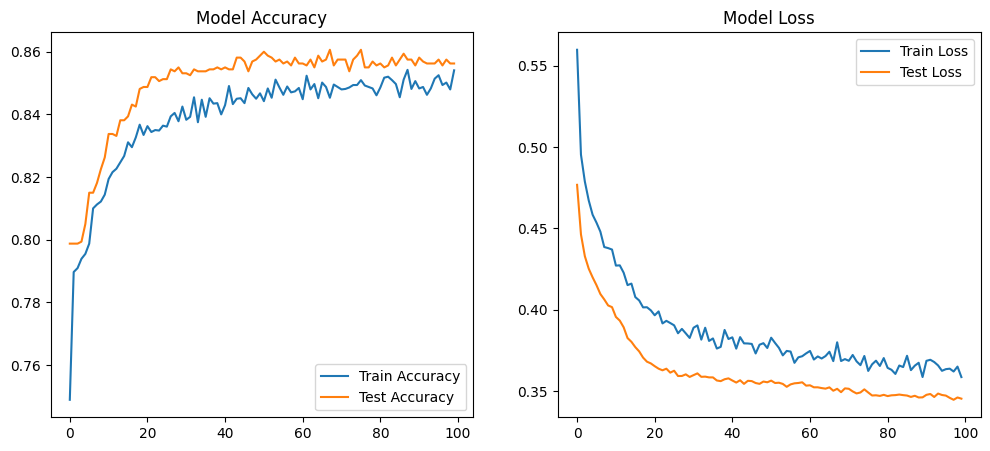

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.legend()
plt.title('Model Loss')
plt.show()


In [ ]:
loss,accuracy=model.evaluate(X_test,y_test)
print(f"Model Accuracy: {accuracy*100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8615 - loss: 0.3360
Model Accuracy: 86.15%


In [ ]:
y_pred=(model.predict(X_test)>0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nOverall Accuracy:", accuracy_score(y_test, y_pred))



Confusion Matrix:
[[1561   46]
 [ 231  162]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1607
           1       0.78      0.41      0.54       393

    accuracy                           0.86      2000
   macro avg       0.82      0.69      0.73      2000
weighted avg       0.85      0.86      0.84      2000


Overall Accuracy: 0.8615


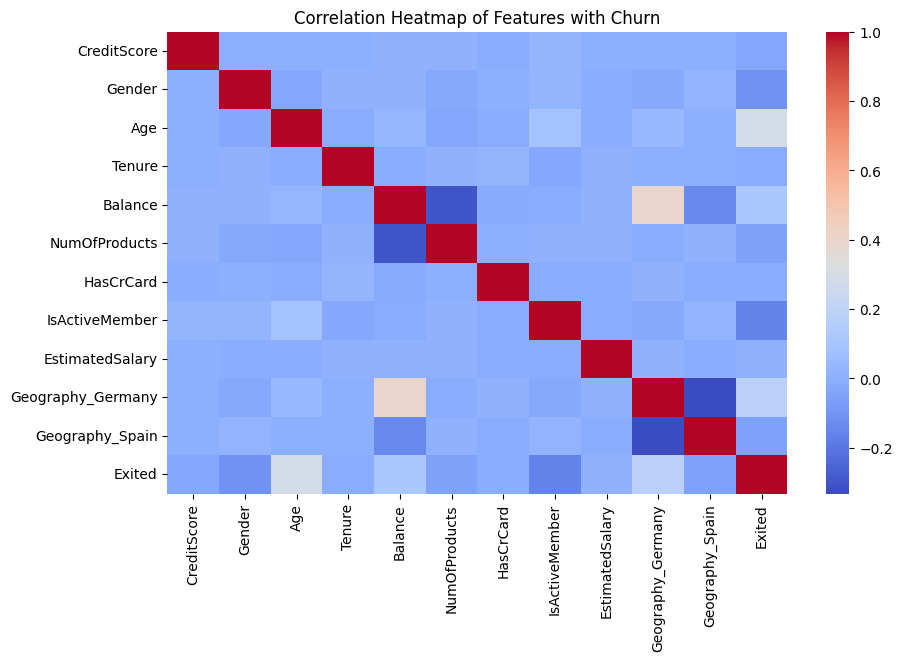

In [ ]:
corr = pd.DataFrame(x, columns=df.drop('Exited', axis=1).columns)
corr['Exited'] = y
plt.figure(figsize=(10,6))
sns.heatmap(corr.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of Features with Churn")
plt.show()
 


In [ ]:

def predict_churn(model, sc, CreditScore, Gender, Age, Tenure, Balance,
                  NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary,
                  Geography):
    
    # Geography Encoding
    geo_Germany = 1 if Geography == 'Germany' else 0
    geo_Spain = 1 if Geography == 'Spain' else 0
    
    # Gender Encoding
    gender = 1 if Gender == 'Male' else 0

    
    input_data = np.array([[CreditScore, gender, Age, Tenure, Balance,
                            NumOfProducts, HasCrCard, IsActiveMember,
                            EstimatedSalary, geo_Germany, geo_Spain]])

    # Scale the input
    input_scaled =sc.transform(input_data)

    # Predict churn
    prediction = model.predict(input_scaled)

    return "⚠️ Will Churn" if prediction[0][0] > 0.5 else "✅ Will Stay"
 


In [ ]:
predict_churn(model, sc,
              CreditScore=650,
              Gender='Male',
              Age=50,
              Tenure=2,
              Balance=120000,
              NumOfProducts=2,
              HasCrCard=1,
              IsActiveMember=0,
              EstimatedSalary=60000,
              Geography='Germany')

 
 

/home/sanjay/Internship/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step


'✅ Will Stay'

**Conclusion**

The Customer Churn Prediction model achieved an accuracy of 86%, effectively identifying customers likely to stay while moderately detecting potential churners. Correlation analysis revealed that Age, Geography, and Customer Activity Level are key churn drivers, whereas features like Credit Score, Balance, and Estimated Salary have minimal impact.
By improving recall through class balancing and feature tuning, this model can help banks proactively retain high-risk customers and enhance overall customer satisfaction.

<!-- Customer Churn Prediction  -->